Random points (lon, lat): [(25.601417530783426, -29.13644224256999), (29.995438327807804, -23.790541171114622)]


AttributeError: 'Element' object has no attribute 'getThumbURL'

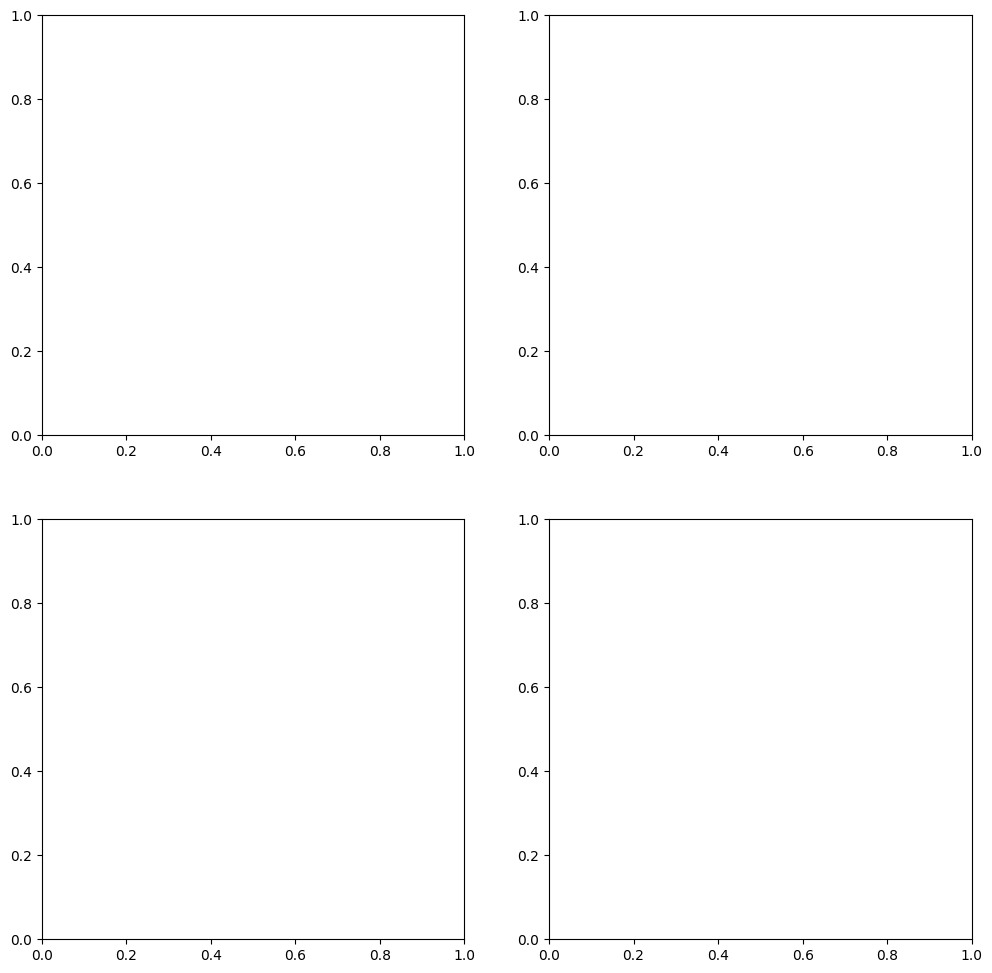

In [2]:
"""
ecosystem_recovery_patches.py

Static visualization script:
- selects a grassland ecoregion from RESOLVE (or use supplied geometry)
- samples 2 random points inside it (different each run)
- downloads 32x32 Landsat RGB patches for 2013 and 2022
- displays side-by-side with a contextily basemap underneath
- shows ECI 2013, ECI 2022, and ECI difference as toggleable layers in map (commented / optional)
"""

import ee

ee.Authenticate(auth_mode='notebook')
ee.Initialize(project = 'ee-gsingh')

import geemap
import requests
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer
import random
import math
import json

In [4]:
PATCH_PIXELS = 32            # patch width/height in pixels (32x32 as requested)
LANDSAT_SCALE = 30           # Landsat native resolution (m)
LANDSAT_BANDS = ['SR_B4', 'SR_B3', 'SR_B2']  # Red, Green, Blue for Landsat (L2/L1 naming)
POINT_COUNT = 2
ECI_2013_ASSET = ee.Image("projects/ee-gsingh/assets/RECOVER/grassECI_2013_300m")
ECI_2022_ASSET = ee.Image("projects/ee-gsingh/assets/RECOVER/grassECI_2022_300m")
RESOLVE_ECO_ID = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017")
SELECTED_ECOREGION_NAME = "Highveld grasslands"  # e.g., "Temperate grasslands, savannas & shrublands"

Random points (lon, lat): [(26.07727021162586, -25.85591858605987), (30.512852348258036, -27.04030447187328)]


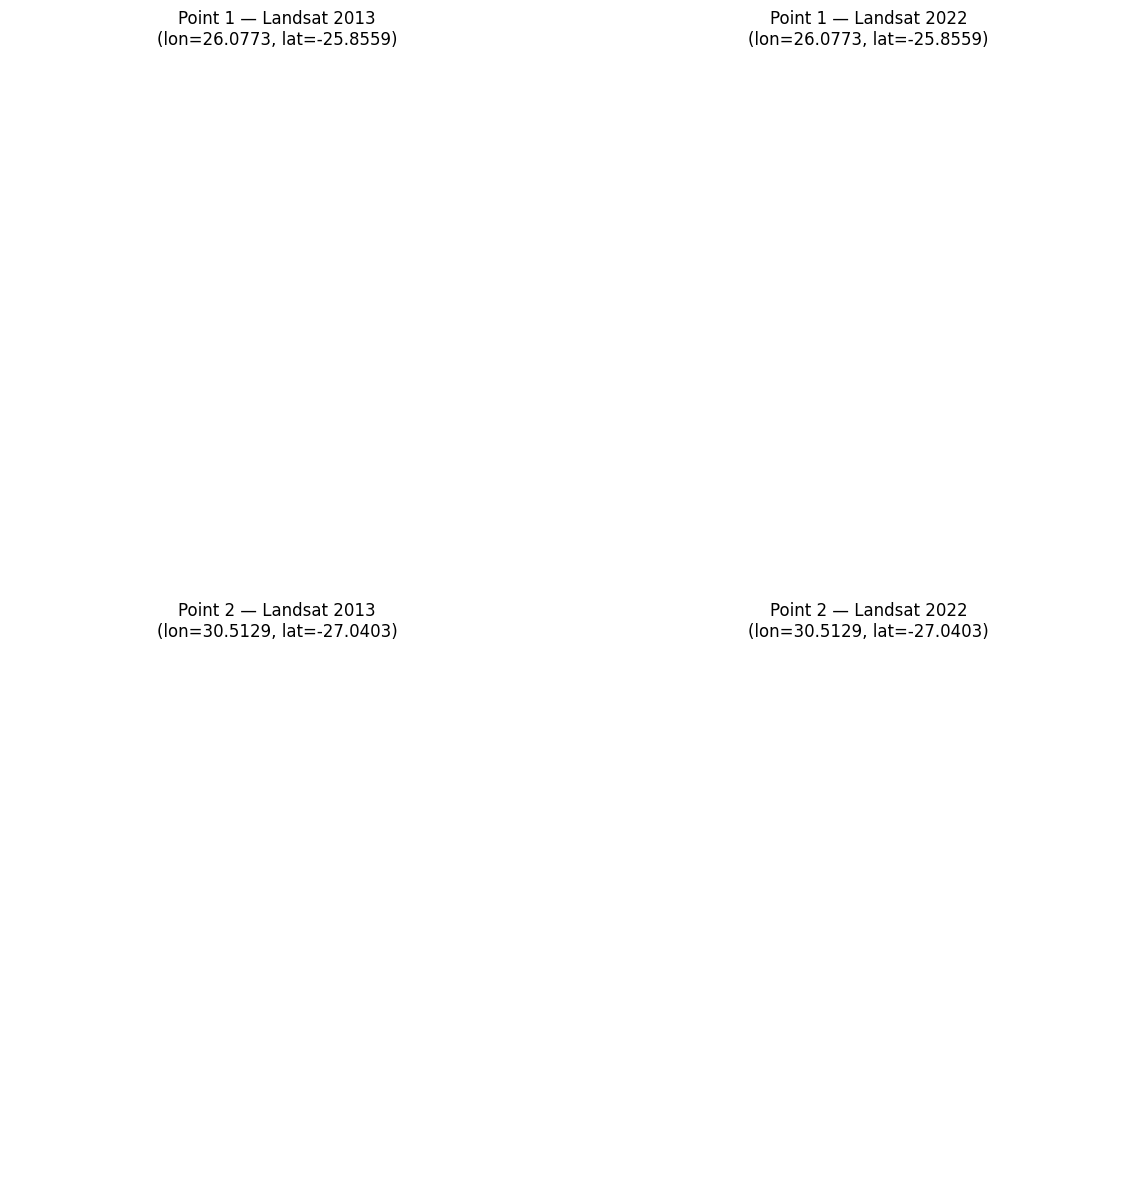

Done. Notes:
- Patches are 32x32 pixels at 30 m (Landsat) → patch roughly 960.0 m per side.
- Random points change every run (seed chosen randomly).
- If you want purely client-only control over the selected ecoregion, set SELECTED_ECOREGION_NAME.
- To enable interactive toggles, uncomment the geemap map block; it will display a folium/geemap widget.


In [5]:


# Helper: pick a grassland ecoregion (or use SELECTED_ECOREGION_NAME)
grass_fc = ee.FeatureCollection(RESOLVE_ECO_ID).filter(ee.Filter.eq('ECO_NAME', SELECTED_ECOREGION_NAME))

# Get geometry of the selected ecoregion
ecoregion_geom = grass_fc.geometry()

# --------------------------
# Create random points inside the ecoregion
# --------------------------
# Use ee.FeatureCollection.randomPoints (region, points, seed)
seed = random.randint(0, 999999)
points_fc = ee.FeatureCollection.randomPoints(region=ecoregion_geom.simplify(100), points=POINT_COUNT, seed=seed)

# Convert to a list to fetch coordinates client-side
points_list = points_fc.toList(POINT_COUNT)

def ee_point_to_latlon(ee_point_feature):
    """Return (lon, lat) tuple for an ee.Feature(Point) by client getInfo."""
    geom = ee.Feature(ee_point_feature).geometry()
    coords = geom.coordinates().getInfo()  # [lon, lat]
    return coords[0], coords[1]

# Resolve points to Python list of (lon, lat)
py_points = []
for i in range(POINT_COUNT):
    feat = points_list.get(i)
    lon, lat = ee_point_to_latlon(feat)
    py_points.append((lon, lat))
print("Random points (lon, lat):", py_points)

# --------------------------
# Prepare Landsat composites for each year
# --------------------------
def landsat_median_image_for_year(year_start, year_end):
    """
    Build a median Landsat surface reflectance composite for the given period.
    2013 -> use Landsat 7/5 (older), 2022 -> Landsat 8.
    Strategy: try Landsat-8 collection first for the year range, fall back to Landsat-7.
    """
    # Landsat 8 L2 (Collection 2, Tier 1)
    s2 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(f"{year_start}-01-01", f"{year_end}-12-31") \
         .filterBounds(ecoregion_geom) \
         .filter(ee.Filter.lt('CLOUD_COVER', 40))
    # If empty, try Landsat 7
    count = s2.size().getInfo()
    if count == 0:
        s2 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2").filterDate(f"{year_start}-01-01", f"{year_end}-12-31") \
             .filterBounds(ecoregion_geom) \
             .filter(ee.Filter.lt('CLOUD_COVER', 30))
    # get median, select RGB bands - map to B4,B3,B2 naming for consistent display
    img = s2.median().select(LANDSAT_BANDS).copyProperties(s2.first(), ['system:time_start'])
    return img

img_2013 = landsat_median_image_for_year(2013, 2014)
img_2022 = landsat_median_image_for_year(2022, 2023)

# --------------------------
# Load ECI images and compute diff
# --------------------------
eci2013 = ECI_2013_ASSET
eci2022 = ECI_2022_ASSET
eci_diff = eci2022.subtract(eci2013)

# --------------------------
# Helper: produce an RGB PIL Image for a given ee.Image centered on lon,lat
# --------------------------
def get_patch_pil(image, lon, lat, patch_pixels=PATCH_PIXELS, scale=LANDSAT_SCALE,
                  bands=LANDSAT_BANDS, min_val=0, max_val=3000):
    """
    Uses ee.Image.getThumbURL to request a square patch centered at lon,lat.
    Returns a PIL.Image.
    """
    # Ensure this is an ee.Image
    if not isinstance(image, ee.image.Image):
        image = ee.Image(image)

    # Build a visualization image (makes sure we get an RGB-renderable object)
    vis_img = image.visualize(bands=bands, min=min_val, max=max_val)

    # Build square region around the point
    half_side_m = (patch_pixels * scale) / 2.0
    center = ee.Geometry.Point([lon, lat])
    region_geo = center.buffer(half_side_m).bounds().getInfo()['coordinates']

    params = {
        'dimensions': f"{patch_pixels}x{patch_pixels}",
        'region': json.dumps(region_geo),
        'format': 'png'
    }

    # getThumbURL works only on an ee.Image with visualization applied
    url = vis_img.getThumbURL(params)

    # Download and convert to PIL
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    return Image.open(BytesIO(resp.content)).convert('RGBA')


# --------------------------
# Helper: get high-res basemap tile (contextily) covering same bbox
# --------------------------
transformer_to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
transformer_to_4326 = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

def bbox_webmercator_for_point(lon, lat, half_side_m):
    x, y = transformer_to_3857.transform(lon, lat)
    xmin, xmax = x - half_side_m, x + half_side_m
    ymin, ymax = y - half_side_m, y + half_side_m
    return xmin, ymin, xmax, ymax

# --------------------------
# Download patches and plot side-by-side
# --------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, (lon, lat) in enumerate(py_points):
    # Get RGB patches
    pil_2013 = get_patch_pil(img_2013, lon, lat, patch_pixels=PATCH_PIXELS, scale=LANDSAT_SCALE)
    pil_2022 = get_patch_pil(img_2022, lon, lat, patch_pixels=PATCH_PIXELS, scale=LANDSAT_SCALE)

    # High-res contextily basemap for same area
    half_side_m = (PATCH_PIXELS * LANDSAT_SCALE) / 2.0
    xmin, ymin, xmax, ymax = bbox_webmercator_for_point(lon, lat, half_side_m)

    # use contextily.bounds2img to request a basemap image (zoom chosen automatically)
    try:
        img_ctx, extent = ctx.bounds2img(xmin, ymin, xmax, ymax, ll=False, zoom=13)  # ll=False since in webmercator
        # bounds2img returns (img, extent) where extent=(xmin, xmax, ymin, ymax) in web mercator coords
    except Exception:
        img_ctx = None
        extent = None

    # plot: axis 0 -> point 0 2013, axis 1 -> point 0 2022; axis 2/3 -> point 1 2013/2022
    ax_2013 = axes[i * 2]
    ax_2022 = axes[i * 2 + 1]

    # Plot contextily basemap as background if available
    if img_ctx is not None:
        # convert extent (webmercator) to latlon for axis extent display
        # extent = (xmin, xmax, ymin, ymax) in webmercator
        # We'll show the basemap then overlay the patch image centered.
        ax_2013.imshow(img_ctx, extent=(extent[0], extent[1], extent[2], extent[3]))
        ax_2022.imshow(img_ctx, extent=(extent[0], extent[1], extent[2], extent[3]))

    # overlay the Landsat thumbnail centered on the same extent
    # Convert the PIL to array and plot with extent covering same bbox
    arr2013 = np.array(pil_2013)
    arr2022 = np.array(pil_2022)

    # If contextily image is present, use its extent; otherwise set a default simple extent
    if extent is not None:
        # extent values for imshow are the bounding box coordinates in webmercator; use same
        ax_2013.imshow(arr2013, extent=(extent[0], extent[1], extent[2], extent[3]))
        ax_2022.imshow(arr2022, extent=(extent[0], extent[1], extent[2], extent[3]))
    else:
        ax_2013.imshow(arr2013)
        ax_2022.imshow(arr2022)

    ax_2013.axis('off')
    ax_2022.axis('off')
    ax_2013.set_title(f"Point {i+1} — Landsat 2013\n(lon={lon:.4f}, lat={lat:.4f})")
    ax_2022.set_title(f"Point {i+1} — Landsat 2022\n(lon={lon:.4f}, lat={lat:.4f})")

plt.tight_layout()
plt.show()

# --------------------------
# OPTIONAL: show ECI layers and diff on an interactive geemap map (toggleable)
# --------------------------
# The user requested static display, but interactive toggleable layers can be useful.
# Uncomment the code below to open an interactive geemap Map with ECI layers and
# the two points drawn. This requires a browser display (Jupyter or local).
"""
m = geemap.Map(center=[py_points[0][1], py_points[0][0]], zoom=8)
m.addLayer(eci2013, {'min':0, 'max':1, 'palette':['#ffffcc','#a1dab4','#41b6c4','#2c7fb8','#253494']}, 'ECI 2013', visible=False)
m.addLayer(eci2022, {'min':0, 'max':1, 'palette':['#ffffcc','#a1dab4','#41b6c4','#2c7fb8','#253494']}, 'ECI 2022', visible=True)
m.addLayer(eci_diff, {'min':-0.5, 'max':0.5, 'palette':['#d7191c','#fdae61','#ffffbf','#a6d96a','#1a9641']}, 'ECI 2022-2013', visible=False)
# add ecoregion outline
m.addLayer(ecoregion_geom, {}, 'Selected Ecoregion')
# add points
for lon, lat in py_points:
    m.addLayer(ee.Feature(ee.Geometry.Point([lon, lat])), {'color':'red'}, 'sample point')
m
"""

print("Done. Notes:")
print("- Patches are 32x32 pixels at 30 m (Landsat) → patch roughly {:.1f} m per side.".format(PATCH_PIXELS * LANDSAT_SCALE))
print("- Random points change every run (seed chosen randomly).")
print("- If you want purely client-only control over the selected ecoregion, set SELECTED_ECOREGION_NAME.")
print("- To enable interactive toggles, uncomment the geemap map block; it will display a folium/geemap widget.")
